In [1]:
import earthaccess
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

## Download Data 

In [2]:
auth = earthaccess.login(persist=True)

In [3]:
# results = earthaccess.search_datasets(instrument="oci")
# for item in results:
#     summary = item.summary()
#     print(summary["short-name"])

In [4]:
results = earthaccess.search_data(
    short_name= "PACE_OCI_L2_CLOUD", 
    # temporal= ("2025-07-01", "2025-07-31"),
    temporal= ("2025-10-02T18:30:00", "2025-10-02T18:40:00"),
    count=1
)
print(len(results))

1


In [6]:
# files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L2_CLOUD_v3_1")

## Load Dataset

In [2]:
path_HARP2 = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_hipp/PACE_HARP2.20251002T182635.L2CLD.V3.5km-20260408T153258Z.nc"
ds_HARP2 = xr.open_dataset(path_HARP2, group='geophysical_data')
geo_HARP2 = xr.open_dataset(path_HARP2, group='geolocation_data')

In [3]:
path_OCI = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L2_CLOUD_v3_1/PACE_OCI.20251002T182635.L2.CLD.V3_1.nc"
ds_OCI = xr.open_dataset(path_OCI, group='geophysical_data')
nav_OCI = xr.open_dataset(path_OCI, group='navigation_data')

In [4]:
HARP2_CER = ds_HARP2['cloud_bow_droplet_effective_radius']
lon_h = geo_HARP2['longitude']
lat_h = geo_HARP2['latitude']

In [5]:
OCI_CER = ds_OCI['cer_21']
lon = nav_OCI['longitude']
lat = nav_OCI['latitude']

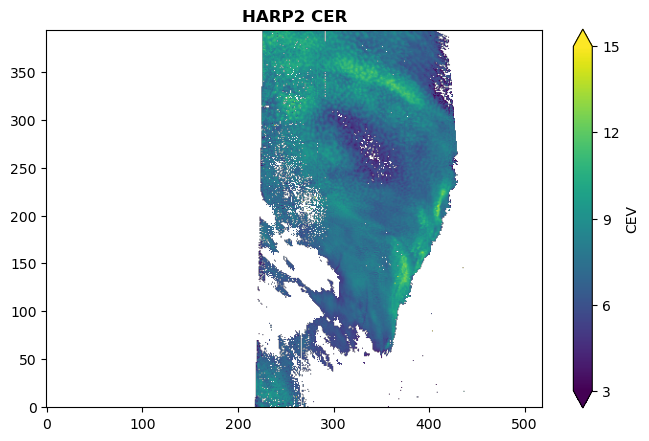

In [6]:
plt.figure(figsize=(8,6))
img = plt.imshow(HARP2_CER, cmap='viridis', vmin=3, vmax=15, origin='lower')
plt.title('HARP2 CER', color='k', fontweight='bold')
plt.colorbar(img, extend='both', ticks=np.arange(3, 16, 3), label='CEV', shrink=0.82)
plt.show()

In [ ]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(8,6))
img = plt.imshow(HARP2_CEV, cmap='viridis', norm=LogNorm(vmin=0.005, vmax=0.33), origin='lower')
plt.title('HARP2 CEV', color='k', fontweight='bold')
cbar= plt.colorbar(img, extend='both', label='CEV', shrink=0.82)
ticks = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.33]
cbar.set_ticks(ticks)
cbar.set_ticklabels([str(t) for t in ticks])

plt.show()

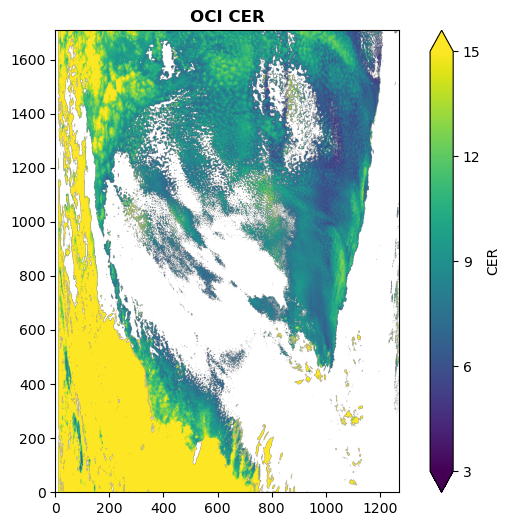

In [7]:
plt.figure(figsize=(8,6))
img = plt.imshow(OCI_CER, cmap='viridis', vmin=3, vmax=15, origin='lower')
plt.title('OCI CER', color='k', fontweight='bold')
plt.colorbar(img, extend='both', ticks=np.arange(3, 16, 3), label='CER',)
plt.show()

In [8]:
y0,x0 = 260,340
y1,x1 = 295,310
y2,x2 = 343,413

CER of pixel 1: nan μm
CER of pixel 2: 5.49 μm
CER of pixel 3: 3.47 μm


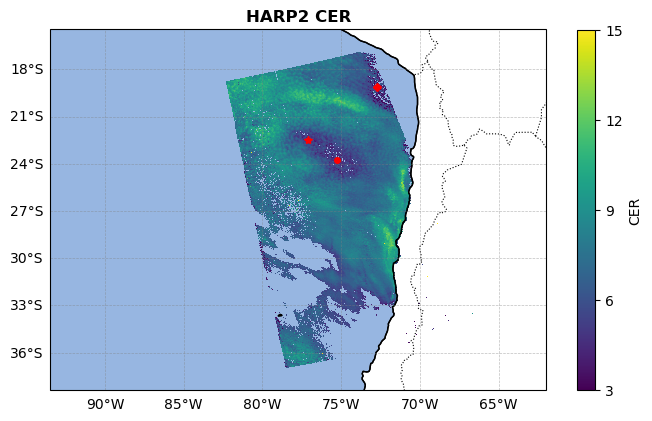

In [9]:
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(lon_h, lat_h, HARP2_CER, vmin=3, vmax=15, cmap='viridis', shading='auto')

ax.plot(lon_h[y0, x0], lat_h[y0, x0], marker='o', color='r', markersize=4, transform=ccrs.PlateCarree())
print(f'CER of pixel 1: {HARP2_CER[y0,x0]:.2f} μm')

ax.plot(lon_h[y1, x1], lat_h[y1, x1], marker='*', color='r', markersize=6, transform=ccrs.PlateCarree())
print(f'CER of pixel 2: {HARP2_CER[y1,x1]:.2f} μm')

ax.plot(lon_h[y2, x2], lat_h[y2, x2], marker='D', color='r', markersize=4, transform=ccrs.PlateCarree())
print(f'CER of pixel 3: {HARP2_CER[y2,x2]:.2f} μm')

ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('HARP2 CER', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', ticks=np.arange(3, 16, 3), shrink=0.78, pad=0.05)
cbar.set_label('CER')

# plt.savefig("HARP2.png", dpi=500, bbox_inches="tight")
plt.show()

CEV of pixel 3: 0.4975


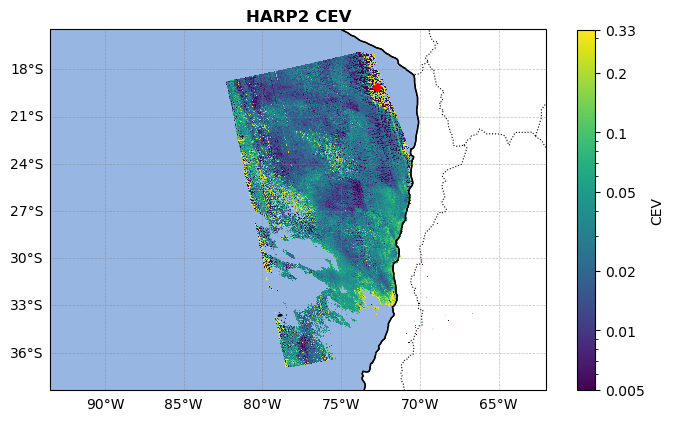

In [10]:
from matplotlib.colors import LogNorm
HARP2_CEV = ds_HARP2['cloud_bow_droplet_effective_variance']

plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(lon_h, lat_h, HARP2_CEV, norm=LogNorm(vmin=0.005, vmax=0.33), cmap='viridis', shading='auto')

# ax.plot(lon_h[y0, x0], lat_h[y0, x0], marker='o', color='r', markersize=4, transform=ccrs.PlateCarree())
# print(f'CEV of pixel 1: {HARP2_CEV[y0,x0]:.2f}')

# ax.plot(lon_h[y1, x1], lat_h[y1, x1], marker='*', color='r', markersize=6, transform=ccrs.PlateCarree())
# print(f'CEV of pixel 2: {HARP2_CEV[y1,x1]:.2f}')

ax.plot(lon_h[y2, x2], lat_h[y2, x2], marker='D', color='r', markersize=4, transform=ccrs.PlateCarree())
print(f'CEV of pixel 3: {HARP2_CEV[y2,x2]:.4f}')

ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('HARP2 CEV', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.78, pad=0.05)

ticks = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.33]
cbar.set_ticks(ticks)
cbar.set_ticklabels([str(t) for t in ticks])

cbar.set_label('CEV')

plt.show()

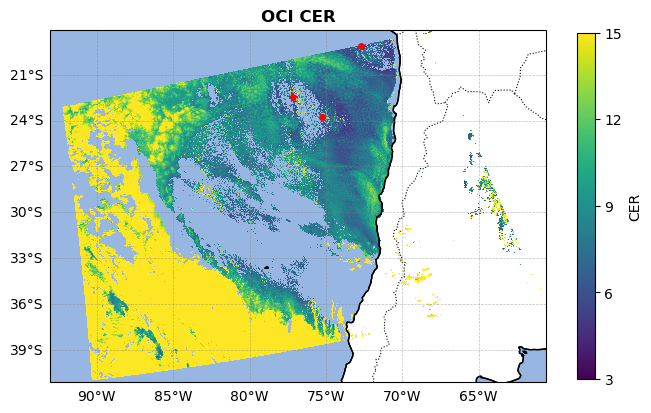

In [11]:
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(lon, lat, OCI_CER, vmin=3, vmax=15, cmap='viridis', shading='auto')

ax.plot(lon_h[y0, x0], lat_h[y0, x0], marker='o', color='r', markersize=4, transform=ccrs.PlateCarree())
ax.plot(lon_h[y1, x1], lat_h[y1, x1], marker='*', color='r', markersize=6, transform=ccrs.PlateCarree())
ax.plot(lon_h[y2, x2], lat_h[y2, x2], marker='o', color='r', markersize=4, transform=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('OCI CER', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', ticks=np.arange(3, 16, 3), shrink=0.75, pad=0.05)
cbar.set_label('CER')

# plt.savefig("OCI.png", dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
OCI_flags = ds_OCI['l2_flags']

plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# y0, x0 = 1334, 965
img = ax.pcolormesh(lon, lat, OCI_flags, cmap='viridis', shading='auto')    

ax.plot(lon_h[y0, x0], lat_h[y0, x0], marker='o', color='r', markersize=4, transform=ccrs.PlateCarree())
print(f'flag of pixel 1: {OCI_flags[1334, 965]:.2f}')

# ax.plot(lon_h[y1, x1], lat_h[y1, x1], marker='*', color='r', markersize=6, transform=ccrs.PlateCarree())
# ax.plot(lon_h[y2, x2], lat_h[y2, x2], marker='o', color='r', markersize=4, transform=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('OCI L2 flags', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.75, pad=0.05)     
cbar.set_label('flag_masks')

# plt.savefig("OCI_flag.png", dpi=500, bbox_inches="tight")
plt.show()

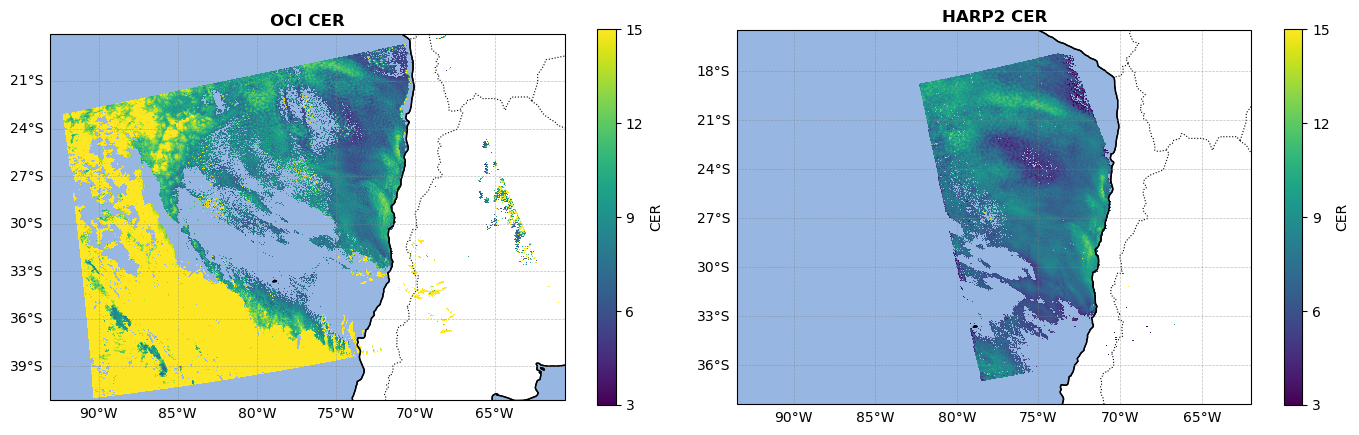

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# First subplot: OCI CER 
im1 = axes[0].pcolormesh(lon, lat, OCI_CER, vmin=3, vmax=15, shading='auto')
axes[0].coastlines()
axes[0].add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
axes[0].add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
axes[0].add_feature(cfeature.OCEAN)
axes[0].set_title('OCI CER', fontsize=12, fontweight='bold')

gl = axes[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                       color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar1 = plt.colorbar(im1, ax=axes[0], ticks=np.arange(3, 16, 3), orientation='vertical', shrink=0.56, pad=0.05)
cbar1.set_label('CER')

# Second subplot: HARP2 CER
im2 = axes[1].pcolormesh(lon_h, lat_h, HARP2_CER, vmin=3, vmax=15, shading='auto')
axes[1].coastlines()
axes[1].add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
axes[1].add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
axes[1].add_feature(cfeature.OCEAN)
axes[1].set_title('HARP2 CER', fontsize=12, fontweight='bold')

gl = axes[1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                       color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar2 = plt.colorbar(im2, ax=axes[1], ticks=np.arange(3, 16, 3), orientation='vertical', shrink=0.56, pad=0.05)
cbar2.set_label('CER')

plt.tight_layout()
# plt.savefig("OCI_HARP2.png", dpi=500, bbox_inches="tight")
plt.show()

In [14]:
lat_target = float(lat_h[y2, x2].values)
lon_target = float(lon_h[y2, x2].values)

lat_oci = nav_OCI['latitude'].values
lon_oci = nav_OCI['longitude'].values

dist = (lat_oci - lat_target)**2 + (lon_oci - lon_target)**2
iy, ix = np.unravel_index(np.nanargmin(dist), dist.shape)

print("HARP2 pixel:", x2, y2)
print("HARP2 lon/lat:", lon_target, lat_target)
print("")
print("Nearest OCI pixel:", ix, iy)
print("Nearest OCI lon/lat:", lon_oci[iy, ix], lat_oci[iy, ix])
print("")
print("HARP2 CER:", HARP2_CER[y2, x2].values if hasattr(HARP2_CER[y2, x2], "values") else HARP2_CER[y2, x2])
print("OCI CER:", float(ds_OCI['cer_21'].values[iy, ix]) if np.isfinite(ds_OCI['cer_21'].values[iy, ix]) else np.nan)

HARP2 pixel: 413 343
HARP2 lon/lat: -72.7096176147461 -19.113079071044922

Nearest OCI pixel: 1147 1704
Nearest OCI lon/lat: -72.69633 -19.11255

HARP2 CER: 3.4728746
OCI CER: nan


In [15]:
# HARP2: target pixel
lat_target = float(lat_h[y2, x2])
lon_target = float(lon_h[y2, x2])

# OCI arrays
lat_oci = nav_OCI['latitude'].values
lon_oci = nav_OCI['longitude'].values
oci_cer = ds_OCI['cer_21'].values

# valid OCI CER only
valid_oci = (np.isfinite(lat_oci) & np.isfinite(lon_oci) & np.isfinite(oci_cer))

# distance from HARP2 target to every OCI pixel
dist2 = (lat_oci - lat_target)**2 + (lon_oci - lon_target)**2
dist = np.sqrt(dist2)

# choose radius in degrees
radius = 0.03   # good starting point for 5 km HARP2 product

# find OCI pixels within radius
near = valid_oci & (dist <= radius)

oci_vals_near = oci_cer[near]

print("HARP2 pixel:", x2, y2)
print("HARP2 lon/lat:", lon_target, lat_target)
print("HARP2 CER:", HARP2_CER[y2, x2].item())
print()
print("Number of OCI pixels in radius:", oci_vals_near.size)

if oci_vals_near.size > 0:
    print("OCI mean CER:", np.nanmean(oci_vals_near))
    # print("OCI std CER:", np.nanstd(oci_vals_near))
    # print("OCI min CER:", np.nanmin(oci_vals_near))
    # print("OCI max CER:", np.nanmax(oci_vals_near))
else:
    print("No valid OCI CER pixels found within radius.")

HARP2 pixel: 413 343
HARP2 lon/lat: -72.7096176147461 -19.113079071044922
HARP2 CER: 3.472874641418457

Number of OCI pixels in radius: 7
OCI mean CER: 7.8523993
